## Build Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (f1_score, precision_score,
                              recall_score, roc_auc_score,
                              classification_report)
from imblearn.over_sampling import (SMOTE,
                                    BorderlineSMOTE,
                                    SVMSMOTE,
                                    ADASYN,
                                    RandomOverSampler)
from imblearn.pipeline import Pipeline as ImbPipeline

np.random.seed(42)
n = 1000

df = pd.DataFrame({
    'transaction_amount'   : np.concatenate([
        np.random.normal(100, 50,  950).clip(1, 500),
        np.random.normal(800, 200,  50).clip(100, 2000)
    ]),
    'transaction_hour'     : np.concatenate([
        np.random.randint(8, 20, 950),
        np.random.randint(0, 24,  50)
    ]).astype(float),
    'num_prev_transactions': np.concatenate([
        np.random.randint(10, 100, 950),
        np.random.randint(0,    5,  50)
    ]).astype(float),
    'distance_from_home'   : np.concatenate([
        np.random.normal(5,  3,  950).clip(0, 20),
        np.random.normal(100, 50, 50).clip(10, 300)
    ]),
})
df['is_fraud'] = [0]*950 + [1]*50

X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Before resampling:")
print(pd.Series(y_train).value_counts())

Before resampling:
is_fraud
0    760
1     40
Name: count, dtype: int64


## Apply All Variants

In [2]:
samplers = {

    'Random Oversampling': RandomOverSampler(
        sampling_strategy = 1.0,
        random_state      = 42
    ),

    'SMOTE': SMOTE(
        sampling_strategy = 1.0,
        # ↑ ratio after resampling
        #   1.0 = equal classes

        k_neighbors       = 5,
        # ↑ number of nearest minority neighbors
        #   to consider when creating synthetic samples
        #   smaller k = tighter synthetic samples (safe)
        #   larger  k = more spread synthetic samples (diverse)

        random_state      = 42
    ),

    'Borderline SMOTE': BorderlineSMOTE(
        sampling_strategy = 1.0,
        k_neighbors       = 5,
        # ↑ neighbors from minority class
        m_neighbors       = 10,
        # ↑ neighbors from ENTIRE dataset (both classes)
        #   used to classify each minority point as
        #   SAFE / DANGER / NOISE
        kind              = 'borderline-1',
        # ↑ 'borderline-1': generate from DANGER points only
        #   'borderline-2': also use majority neighbors
        #                   for direction of synthesis
        random_state      = 42
    ),

    'SVMSMOTE': SVMSMOTE(
        sampling_strategy = 1.0,
        k_neighbors       = 5,
        # ↑ neighbors for generating synthetic samples
        m_neighbors       = 10,
        # ↑ neighbors for deciding where to generate
        random_state      = 42
    ),

    'ADASYN': ADASYN(
        sampling_strategy = 1.0,
        n_neighbors       = 5,
        # ↑ neighbors used to calculate density/difficulty
        #   and to generate synthetic samples
        random_state      = 42
    ),
}

results = {}

for name, sampler in samplers.items():
    try:
        pipe = ImbPipeline([
            ('sampler', sampler),
            ('scaler',  StandardScaler()),
            ('model',   RandomForestClassifier(
                            n_estimators=100, random_state=42))
        ])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        y_prob = pipe.predict_proba(X_test)[:, 1]

        # Check resampled distribution
        X_res, y_res = sampler.fit_resample(X_train, y_train)

        results[name] = {
            'F1'       : f1_score(y_test, y_pred, zero_division=0),
            'Precision': precision_score(y_test, y_pred,
                                         zero_division=0),
            'Recall'   : recall_score(y_test, y_pred),
            'AUC'      : roc_auc_score(y_test, y_prob),
            'Majority' : (y_res == 0).sum(),
            'Minority' : (y_res == 1).sum(),
        }

        print(f"\n{name}")
        print(f"  After resampling → "
              f"Majority: {results[name]['Majority']}, "
              f"Minority: {results[name]['Minority']}")
        print(f"  F1: {results[name]['F1']:.3f}  "
              f"Recall: {results[name]['Recall']:.3f}  "
              f"AUC: {results[name]['AUC']:.3f}")

    except Exception as e:
        print(f"\n{name} → Error: {e}")


Random Oversampling
  After resampling → Majority: 760, Minority: 760
  F1: 1.000  Recall: 1.000  AUC: 1.000

SMOTE
  After resampling → Majority: 760, Minority: 760
  F1: 1.000  Recall: 1.000  AUC: 1.000

Borderline SMOTE
  After resampling → Majority: 760, Minority: 760
  F1: 1.000  Recall: 1.000  AUC: 1.000

SVMSMOTE
  After resampling → Majority: 760, Minority: 760
  F1: 1.000  Recall: 1.000  AUC: 1.000

ADASYN
  After resampling → Majority: 760, Minority: 760
  F1: 1.000  Recall: 1.000  AUC: 1.000


## Visualize Synthetic Samples in 2D

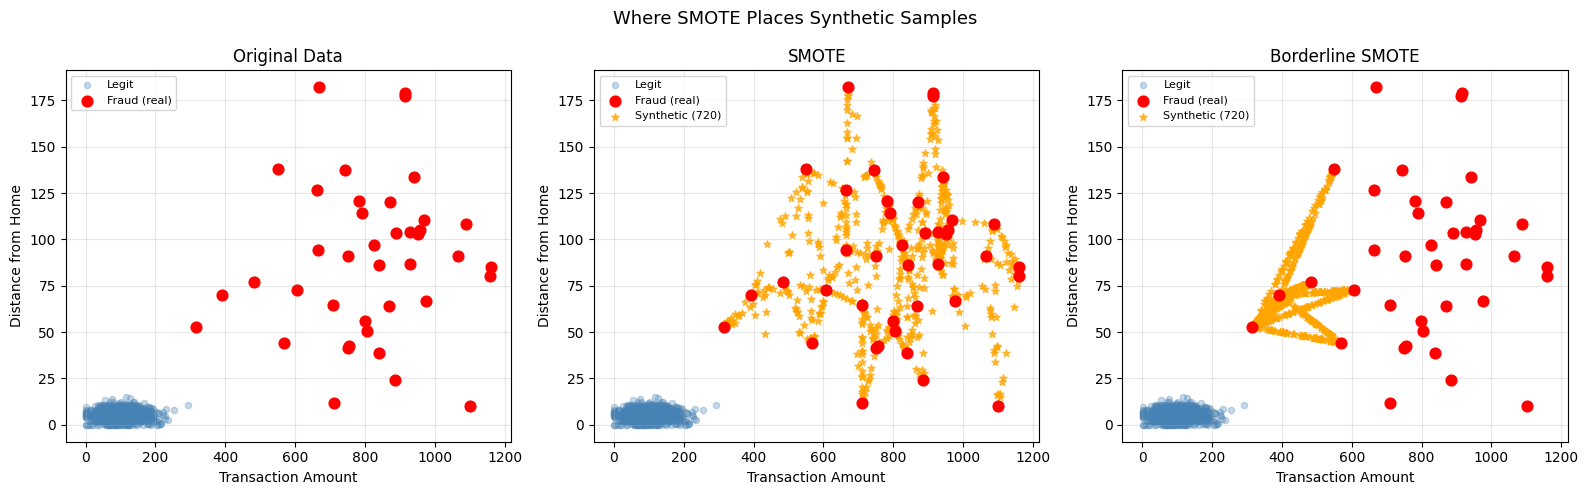

In [6]:
# Use 2 features to see where SMOTE places synthetic samples
X_2d = df[['transaction_amount', 'distance_from_home']].values
y_2d = df['is_fraud'].values

X_train_2d, _, y_train_2d, _ = train_test_split(
    X_2d, y_2d, test_size=0.2, stratify=y_2d, random_state=42
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

smote_variants_2d = {
    'Original Data'    : None,
    'SMOTE'            : SMOTE(k_neighbors=5, random_state=42),
    'Borderline SMOTE' : BorderlineSMOTE(k_neighbors=5, random_state=42),
}

for ax, (name, sampler) in zip(axes, smote_variants_2d.items()):

    if sampler is None:
        X_plot, y_plot = X_train_2d, y_train_2d
        n_synthetic = 0
    else:
        X_res, y_res = sampler.fit_resample(X_train_2d, y_train_2d)

        # Original minority points
        orig_minority_mask = y_train_2d == 1

        # All minority points after resampling
        res_minority_mask  = y_res == 1

        # Synthetic = resampled minority - original minority
        n_orig_minority  = orig_minority_mask.sum()
        n_synthetic      = res_minority_mask.sum() - n_orig_minority

        X_plot, y_plot = X_res, y_res

    # Plot majority
    mask_maj = y_plot == 0
    ax.scatter(X_plot[mask_maj, 0], X_plot[mask_maj, 1],
               c='steelblue', alpha=0.3, s=20, label='Legit')

    if sampler is None:
        # Original minority
        mask_min = y_plot == 1
        ax.scatter(X_plot[mask_min, 0], X_plot[mask_min, 1],
                   c='red', s=60, label='Fraud (real)', zorder=5)
    else:
        # Original minority (first n_orig_minority points)
        X_res_min = X_res[y_res == 1]
        ax.scatter(X_res_min[:n_orig_minority, 0],
                   X_res_min[:n_orig_minority, 1],
                   c='red', s=60, label='Fraud (real)', zorder=5)

        # Synthetic minority (remaining points)
        ax.scatter(X_res_min[n_orig_minority:, 0],
                   X_res_min[n_orig_minority:, 1],
                   c='orange', s=30, marker='*',
                   label=f'Synthetic ({n_synthetic})', zorder=4,
                   alpha=0.7)

    ax.set_xlabel("Transaction Amount")
    ax.set_ylabel("Distance from Home")
    ax.set_title(name)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Where SMOTE Places Synthetic Samples", fontsize=13)
plt.tight_layout()
plt.show()

## Compare All Metrics


Full Comparison:
                      F1  Precision  Recall  AUC
Random Oversampling  1.0        1.0     1.0  1.0
SMOTE                1.0        1.0     1.0  1.0
Borderline SMOTE     1.0        1.0     1.0  1.0
SVMSMOTE             1.0        1.0     1.0  1.0
ADASYN               1.0        1.0     1.0  1.0


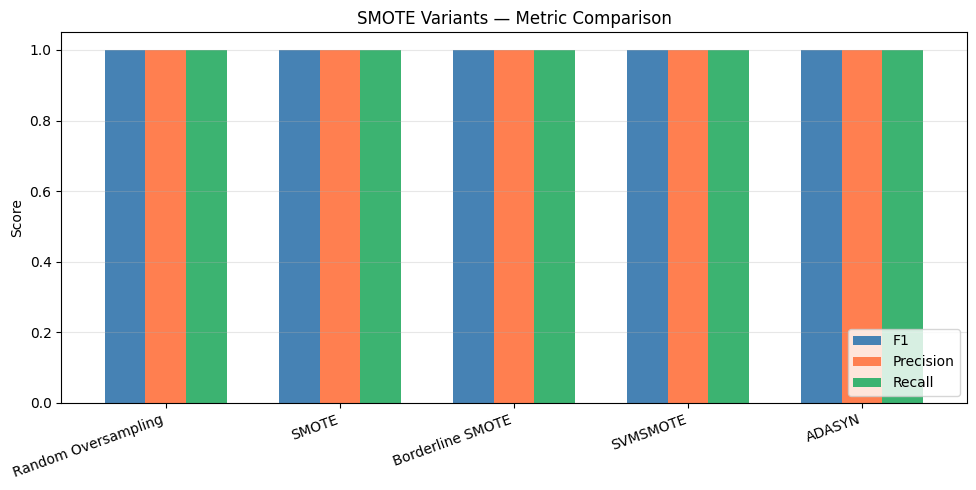

In [7]:
results_df = pd.DataFrame(results).T[['F1','Precision','Recall','AUC']]
print("\nFull Comparison:")
print(results_df.round(3))

results_df[['F1', 'Precision', 'Recall']].plot(
    kind    = 'bar',
    figsize = (10, 5),
    color   = ['steelblue', 'coral', 'mediumseagreen'],
    width   = 0.7
)
plt.title("SMOTE Variants — Metric Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20, ha='right')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()